# EDA — Customer Support Ticket Dataset

Análise exploratória do dataset que serve de base ao sistema de atendimento ao cliente com IA.

## 1. Compreensão do problema e do dataset

### 1.1 Problema

O sistema a ser construído recebe o texto livre de um chamado de suporte e precisa identificar a **intenção** do
cliente para rotear o atendimento (dúvida técnica, cobrança, cancelamento, reembolso, informação de produto).
O objetivo desta EDA é responder: *quais variáveis descrevem um chamado, qual é a qualidade delas e onde está o
sinal que permite inferir a intenção?*

### 1.2 Fonte

| Item | Descrição |
|---|---|
| Nome | Customer Support Ticket Dataset |
| Autor | Suraj Jha (`suraj520`) |
| Origem | https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset |
| Licença | CC0 1.0 (domínio público) |
| Arquivo | `customer_support_tickets.csv` |
| Natureza | Dados **sintéticos**, gerados artificialmente para fins didáticos — não contêm dados reais de clientes |

### 1.3 Principais características

- 8.469 registros e 17 colunas, um registro por chamado.
- **Identificação e perfil do cliente:** `Ticket ID`, `Customer Name`, `Customer Email`, `Customer Age`,
  `Customer Gender`.
- **Produto:** `Product Purchased` (42 produtos de eletrônicos de consumo), `Date of Purchase`.
- **Classificação do chamado:** `Ticket Type` (5 classes — o alvo natural do classificador de intenção),
  `Ticket Subject` (16 assuntos), `Ticket Priority` (4 níveis), `Ticket Channel` (4 canais).
- **Texto livre:** `Ticket Description` — a única variável de conteúdo, insumo do modelo de NLP.
- **Ciclo de vida e desfecho:** `Ticket Status`, `Resolution`, `First Response Time`, `Time to Resolution`,
  `Customer Satisfaction Rating` (1 a 5).

### 1.4 Motivo da escolha

1. **Aderência ao domínio.** É um dataset de tickets de suporte com texto livre e uma taxonomia de intenções
   pronta (`Ticket Type`), exatamente o par entrada/saída da rota `/predict` da API.
2. **Riqueza de tipos.** Combina texto, categóricas, numéricas e temporais, permitindo exercitar todas as etapas
   da EDA (qualidade, limpeza, univariada) em um único conjunto.
3. **Ausência de risco de privacidade.** Sendo sintético e licenciado como CC0, pode ser versionado no
   repositório público sem exposição de PII real — ainda assim ele *simula* PII (nome, e-mail), o que permite
   tratar a proteção desses campos como requisito de projeto.
4. **Volume adequado.** ~8,5 mil registros: suficiente para treinar e validar um classificador nas próximas
   entregas e leve o bastante para iteração rápida.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, kstest, uniform

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "../data/customer_support_tickets.csv"
RANDOM_STATE = 42

## 2. Inspeção inicial

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Linhas: {df.shape[0]}  |  Colunas: {df.shape[1]}")
df.head()

Linhas: 8469  |  Colunas: 17


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [4]:
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [5]:
df.describe(include="object").T

,count,unique,top,freq
Customer Name,8469,8028,Michael Garcia,5
Customer Email,8469,8320,asmith@example.com,4
Customer Gender,8469,3,Male,2896
Product Purchased,8469,42,Canon EOS,240
Date of Purchase,8469,730,2020-10-21,24
Ticket Type,8469,5,Refund request,1752
Ticket Subject,8469,16,Refund request,576
Ticket Description,8469,8077,I'm having an issue with the {product_purchase...,25
Ticket Status,8469,3,Pending Customer Response,2881
Resolution,2769,2769,We seat culture plan.,1


## 3. Verificação da qualidade dos dados

In [6]:
qualidade = pd.DataFrame({
    "nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(),
    "tipo": df.dtypes.astype(str),
})
qualidade.sort_values("%_nulos", ascending=False)

,nulos,%_nulos,unicos,tipo
Customer Satisfaction Rating,5700,67.30,5,float64
Resolution,5700,67.30,2769,object
Time to Resolution,5700,67.30,2728,object
First Response Time,2819,33.29,5470,object
Ticket ID,0,0.00,8469,int64
Customer Name,0,0.00,8028,object
Customer Email,0,0.00,8320,object
Customer Age,0,0.00,53,int64
Customer Gender,0,0.00,3,object
Ticket Subject,0,0.00,16,object


Quatro colunas concentram todos os valores ausentes. Antes de imputar ou descartar, é preciso checar se a
ausência é aleatória ou consequência do ciclo de vida do chamado.

In [7]:
for col in ["First Response Time", "Time to Resolution", "Resolution", "Customer Satisfaction Rating"]:
    print(f"--- {col} (True = ausente) ---")
    print(pd.crosstab(df["Ticket Status"], df[col].isna()), end="\n\n")

--- First Response Time (True = ausente) ---
First Response Time        False  True 
Ticket Status                          
Closed                      2769      0
Open                           0   2819
Pending Customer Response   2881      0

--- Time to Resolution (True = ausente) ---
Time to Resolution         False  True 
Ticket Status                          
Closed                      2769      0
Open                           0   2819
Pending Customer Response      0   2881

--- Resolution (True = ausente) ---
Resolution                 False  True 
Ticket Status                          
Closed                      2769      0
Open                           0   2819
Pending Customer Response      0   2881

--- Customer Satisfaction Rating (True = ausente) ---
Customer Satisfaction Rating  False  True 
Ticket Status                             
Closed                         2769      0
Open                              0   2819
Pending Customer Response         0   2881



A ausência é **estrutural**, não um defeito de coleta: chamados `Open` ainda não têm primeira resposta;
apenas chamados `Closed` têm resolução, tempo de resolução e nota de satisfação. Imputar esses campos
introduziria informação falsa — eles devem permanecer nulos e ser lidos como "evento ainda não ocorreu".

In [8]:
print(f"Linhas totalmente duplicadas : {df.duplicated().sum()}")
print(f"Ticket ID duplicados         : {df['Ticket ID'].duplicated().sum()}")
print(f"E-mails repetidos            : {df['Customer Email'].duplicated().sum()}")
print(f"Descrições repetidas         : {df['Ticket Description'].duplicated().sum()} "
      f"({df['Ticket Description'].duplicated().mean():.1%})")

Linhas totalmente duplicadas : 0
Ticket ID duplicados         : 0
E-mails repetidos            : 149
Descrições repetidas         : 392 (4.6%)


In [9]:
categoricas = ["Customer Gender", "Ticket Type", "Ticket Subject", "Ticket Status",
               "Ticket Priority", "Ticket Channel", "Product Purchased"]
for col in categoricas:
    print(f"{col:<20} -> {df[col].nunique():>3} categorias | {sorted(df[col].unique())[:5]}...")

Customer Gender      ->   3 categorias | ['Female', 'Male', 'Other']...
Ticket Type          ->   5 categorias | ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']...
Ticket Subject       ->  16 categorias | ['Account access', 'Battery life', 'Cancellation request', 'Data loss', 'Delivery problem']...
Ticket Status        ->   3 categorias | ['Closed', 'Open', 'Pending Customer Response']...
Ticket Priority      ->   4 categorias | ['Critical', 'High', 'Low', 'Medium']...
Ticket Channel       ->   4 categorias | ['Chat', 'Email', 'Phone', 'Social media']...
Product Purchased    ->  42 categorias | ['Adobe Photoshop', 'Amazon Echo', 'Amazon Kindle', 'Apple AirPods', 'Asus ROG']...


In [10]:
print("Idade    :", df["Customer Age"].min(), "a", df["Customer Age"].max())
print("Satisfação:", df["Customer Satisfaction Rating"].min(), "a", df["Customer Satisfaction Rating"].max())

datas = {c: pd.to_datetime(df[c]) for c in ["Date of Purchase", "First Response Time", "Time to Resolution"]}
for nome, serie in datas.items():
    print(f"{nome:<20}: {serie.min()} -> {serie.max()}")

delta_h = (datas["Time to Resolution"] - datas["First Response Time"]).dt.total_seconds() / 3600
print(f"\nResolução anterior à primeira resposta: {(delta_h < 0).sum()} casos "
      f"({(delta_h < 0).sum() / delta_h.notna().sum():.1%} dos chamados fechados)")

Idade    : 18 a 70
Satisfação: 1.0 a 5.0
Date of Purchase    : 2020-01-01 00:00:00 -> 2021-12-30 00:00:00
First Response Time : 2023-05-31 21:55:39 -> 2023-06-02 00:54:21
Time to Resolution  : 2023-05-31 21:53:30 -> 2023-06-02 00:55:33

Resolução anterior à primeira resposta: 1365 casos (49.3% dos chamados fechados)


Três inconsistências relevantes:

1. As compras ocorrem entre 2020 e 2021, mas **todos** os carimbos de atendimento caem em uma janela de ~27
   horas (31/05/2023 a 02/06/2023) — os timestamps foram sorteados, não gerados pelo processo de atendimento.
2. Em cerca de metade dos chamados fechados a resolução antecede a primeira resposta, o que é logicamente
   impossível.

Consequência: `First Response Time` e `Time to Resolution` **não podem sustentar análises de SLA** e serão
excluídos das features do modelo.

In [11]:
placeholder = df["Ticket Description"].str.contains(r"\{product_purchased\}", regex=True)
print(f"Descrições com o marcador '{{product_purchased}}': {placeholder.mean():.1%}")
print("\nExemplo:\n", df.loc[0, "Ticket Description"][:300])

Descrições com o marcador '{product_purchased}': 100.0%

Exemplo:
 I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.


**Síntese da qualidade**

| Achado | Impacto | Tratamento |
|---|---|---|
| Nulos estruturais em 4 colunas | Nenhum, se interpretados corretamente | Manter nulos; derivar flag `chamado_fechado` |
| Marcador `{product_purchased}` em 100% do texto | Ruído de vocabulário no NLP | Substituir pelo produto real |
| Timestamps de atendimento incoerentes | Impede análise de SLA | Descartar como feature |
| Nome e e-mail do cliente (PII simulada) | Risco de exposição | Remover do dataset de trabalho |
| Sem duplicatas de linha ou de `Ticket ID` | Nenhum | — |

## 4. Limpeza e preparação dos dados

In [12]:
PII = ["Customer Name", "Customer Email"]
COLUNAS_DESCARTADAS = ["First Response Time", "Time to Resolution"]

dados = df.drop(columns=PII + COLUNAS_DESCARTADAS).copy()
dados.columns = (dados.columns.str.lower().str.replace(" ", "_"))

dados["date_of_purchase"] = pd.to_datetime(dados["date_of_purchase"])
dados["purchase_year"] = dados["date_of_purchase"].dt.year

dados["ticket_priority"] = pd.Categorical(
    dados["ticket_priority"], categories=["Low", "Medium", "High", "Critical"], ordered=True
)
for col in ["customer_gender", "ticket_type", "ticket_subject", "ticket_status",
            "ticket_channel", "product_purchased"]:
    dados[col] = dados[col].astype("category")

dados["ticket_text"] = [
    desc.replace("{product_purchased}", prod)
    for desc, prod in zip(dados["ticket_description"], dados["product_purchased"].astype(str))
]
dados["ticket_text"] = (dados["ticket_text"]
                        .str.replace(r"\s+", " ", regex=True)
                        .str.strip())

dados["text_char_count"] = dados["ticket_text"].str.len()
dados["text_word_count"] = dados["ticket_text"].str.split().str.len()
dados["is_closed"] = (dados["ticket_status"] == "Closed")

dados = dados.drop(columns=["ticket_description"])
print(f"Shape após limpeza: {dados.shape}")
dados.head(3)

Shape após limpeza: (8469, 17)


,ticket_id,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_status,resolution,ticket_priority,ticket_channel,customer_satisfaction_rating,purchase_year,ticket_text,text_char_count,text_word_count,is_closed
0,1,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,NaN,2021,I'm having an issue with the GoPro Hero. Pleas...,272,44,False
1,2,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,NaN,Critical,Chat,NaN,2021,I'm having an issue with the LG Smart TV. Plea...,263,48,False
2,3,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,3.0,2020,I'm facing a problem with my Dell XPS. The Del...,241,45,True


In [13]:
print("PII removida       :", not any(c in dados.columns for c in ["customer_name", "customer_email"]))
print("Marcador residual  :", dados["ticket_text"].str.contains(r"\{.*?\}", regex=True).sum())
print("Nulos remanescentes:")
print(dados.isna().sum()[lambda s: s > 0])
dados.dtypes

PII removida       : True
Marcador residual  : 816
Nulos remanescentes:
resolution                      5700
customer_satisfaction_rating    5700
dtype: int64


ticket_id                                int64
customer_age                             int64
customer_gender                       category
product_purchased                     category
date_of_purchase                datetime64[ns]
ticket_type                           category
ticket_subject                        category
ticket_status                         category
resolution                              object
ticket_priority                       category
ticket_channel                        category
customer_satisfaction_rating           float64
purchase_year                            int32
ticket_text                             object
text_char_count                          int64
text_word_count                          int64
is_closed                                 bool
dtype: object

## 5. Análise univariada

### 5.1 Variáveis numéricas

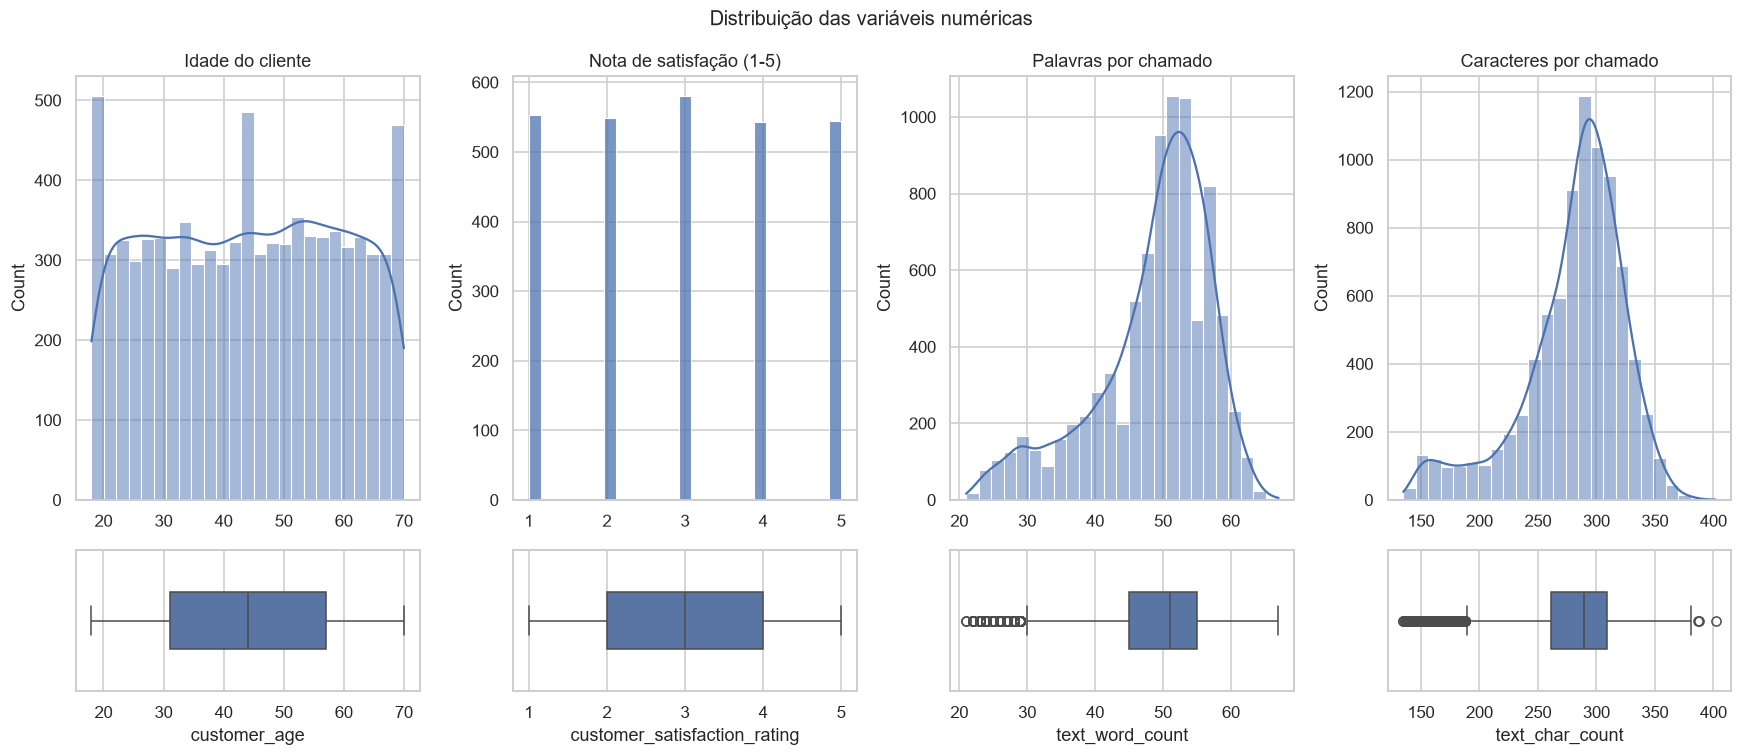

,mean,std,min,median,max,skew
customer_age,44.03,15.30,18.0,44.0,70.0,-0.02
customer_satisfaction_rating,2.99,1.41,1.0,3.0,5.0,0.01
text_word_count,48.54,8.62,21.0,51.0,67.0,-0.99
text_char_count,280.66,44.07,135.0,289.0,402.0,-1.03


In [14]:
numericas = ["customer_age", "customer_satisfaction_rating", "text_word_count", "text_char_count"]
titulos = ["Idade do cliente", "Nota de satisfação (1-5)", "Palavras por chamado", "Caracteres por chamado"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), gridspec_kw={"height_ratios": [3, 1]})
for i, (col, titulo) in enumerate(zip(numericas, titulos)):
    sns.histplot(dados[col].dropna(), bins=25, kde=(col != "customer_satisfaction_rating"), ax=axes[0, i])
    axes[0, i].set_title(titulo)
    axes[0, i].set_xlabel("")
    sns.boxplot(x=dados[col].dropna(), ax=axes[1, i], width=0.4)
    axes[1, i].set_xlabel(col)
fig.suptitle("Distribuição das variáveis numéricas", fontsize=13)
fig.tight_layout()
plt.show()

dados[numericas].agg(["mean", "std", "min", "median", "max", "skew"]).T.round(2)

`customer_age` cobre 18–70 sem concentração em nenhuma faixa; `customer_satisfaction_rating` distribui-se
quase uniformemente entre 1 e 5 (média 2,99), ou seja, não há viés de satisfação. O texto é curto e homogêneo:
mediana de 51 palavras e desvio de 8,6, com assimetria negativa leve (−1,0) — a única cauda é um grupo pequeno
de chamados mais sucintos, e não há valores extremos capazes de distorcer a modelagem.

### 5.2 Variáveis categóricas

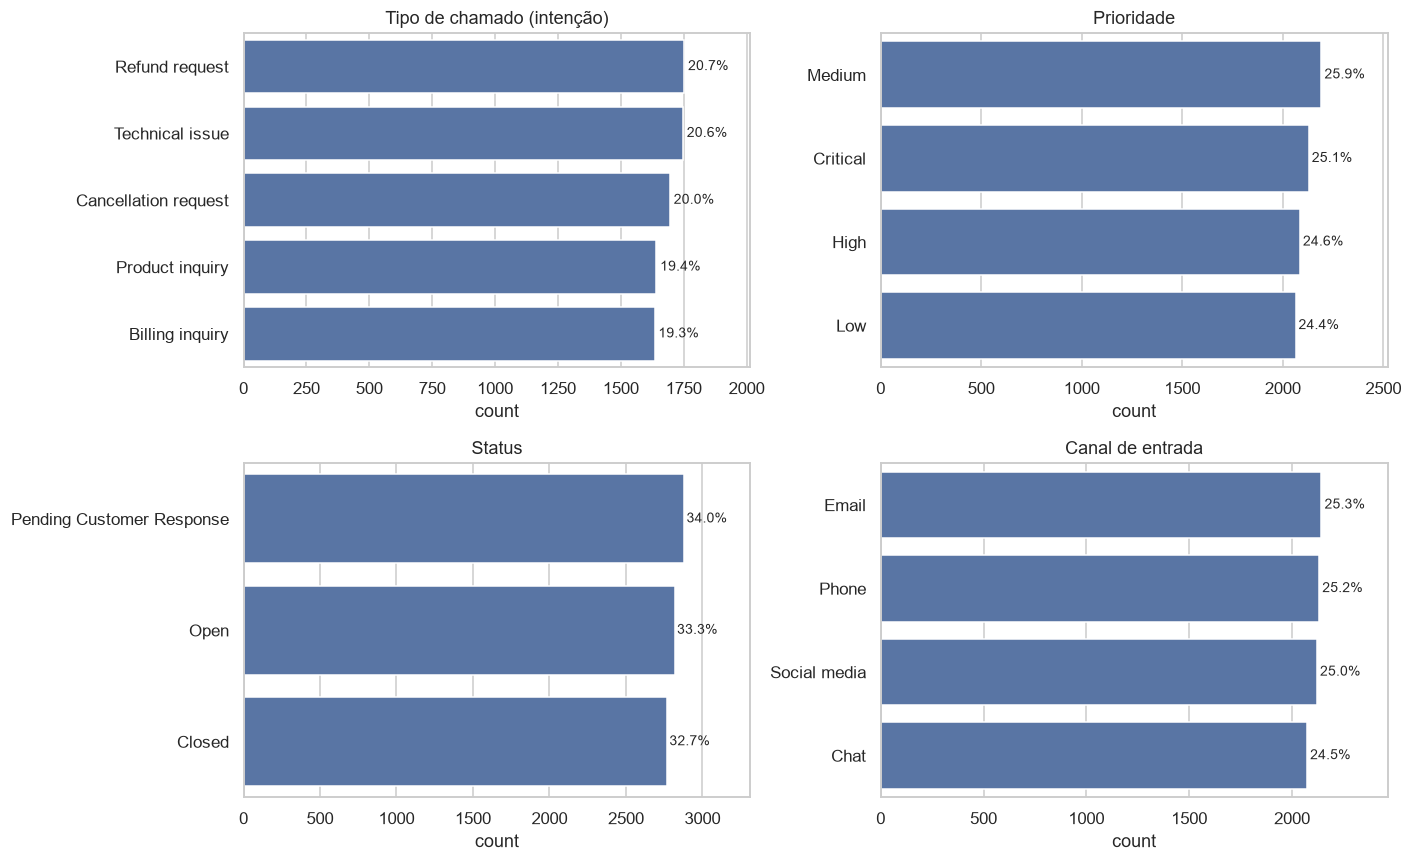

ticket_type
Refund request          0.2069
Technical issue         0.2063
Cancellation request    0.2001
Product inquiry         0.1938
Billing inquiry         0.1929
Name: proportion, dtype: float64

In [15]:
principais = ["ticket_type", "ticket_priority", "ticket_status", "ticket_channel"]
rotulos = ["Tipo de chamado (intenção)", "Prioridade", "Status", "Canal de entrada"]

total = len(dados)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col, rotulo in zip(axes.ravel(), principais, rotulos):
    contagem = dados[col].value_counts()
    sns.countplot(data=dados, y=col, order=contagem.index, ax=ax)
    ax.set_title(rotulo)
    ax.set_ylabel("")
    for p in ax.patches:
        ax.annotate(f"{p.get_width() / total:.1%}", (p.get_width() + 15, p.get_y() + p.get_height() / 2),
                    va="center", fontsize=9)
    ax.set_xlim(0, contagem.max() * 1.15)
fig.tight_layout()
plt.show()

dados["ticket_type"].value_counts(normalize=True).round(4)

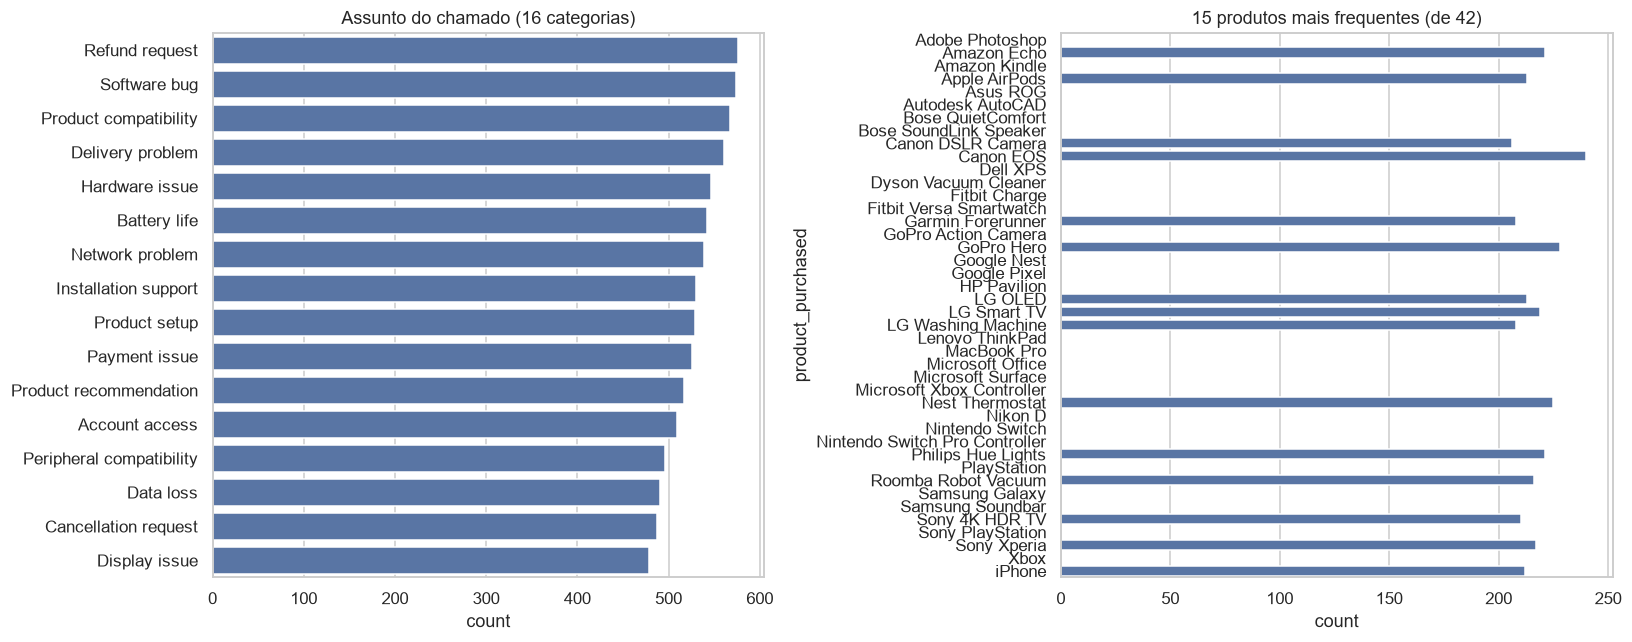

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=dados, y="ticket_subject", order=dados["ticket_subject"].value_counts().index, ax=axes[0])
axes[0].set_title("Assunto do chamado (16 categorias)")
axes[0].set_ylabel("")

top_produtos = dados["product_purchased"].value_counts().head(15)
sns.barplot(x=top_produtos.values, y=top_produtos.index, ax=axes[1])
axes[1].set_title("15 produtos mais frequentes (de 42)")
axes[1].set_xlabel("count")
fig.tight_layout()
plt.show()

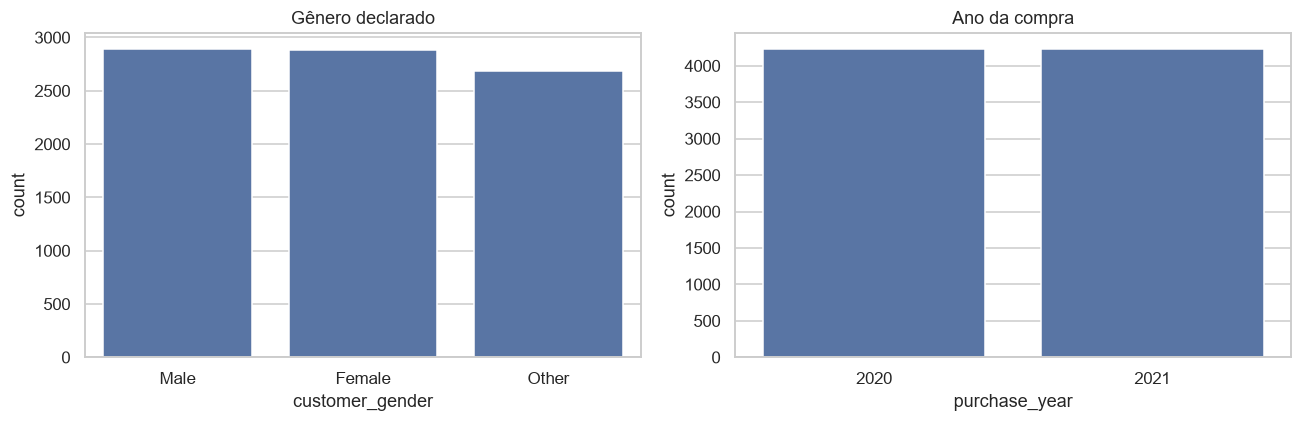

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=dados, x="customer_gender", order=dados["customer_gender"].value_counts().index, ax=axes[0])
axes[0].set_title("Gênero declarado")
sns.countplot(data=dados, x="purchase_year", ax=axes[1])
axes[1].set_title("Ano da compra")
fig.tight_layout()
plt.show()

### 5.3 Verificação estatística do equilíbrio

As frequências acima sugerem distribuições próximas do uniforme. Dois testes formais confirmam a leitura:
Kolmogorov–Smirnov para a idade e qui-quadrado de independência entre os metadados categóricos e a intenção.

In [18]:
ks = kstest(dados["customer_age"], uniform(loc=18, scale=52).cdf)
print(f"KS idade vs. Uniforme(18, 70): D={ks.statistic:.4f}  p={ks.pvalue:.4g}")

print("\nQui-quadrado de independência contra 'ticket_type':")
for col in ["ticket_subject", "ticket_priority", "ticket_channel", "customer_gender"]:
    tabela = pd.crosstab(dados["ticket_type"], dados[col])
    chi2, p, dof, _ = chi2_contingency(tabela)
    print(f"  {col:<18} chi2={chi2:7.2f}  gl={dof:>3}  p={p:.4f}  ->"
          f" {'dependente' if p < 0.05 else 'independente'}")

KS idade vs. Uniforme(18, 70): D=0.0212  p=0.0009968

Qui-quadrado de independência contra 'ticket_type':
  ticket_subject     chi2=  39.57  gl= 60  p=0.9807  -> independente
  ticket_priority    chi2=  10.63  gl= 12  p=0.5613  -> independente
  ticket_channel     chi2=  11.85  gl= 12  p=0.4578  -> independente
  customer_gender    chi2=   5.85  gl=  8  p=0.6641  -> independente


In [19]:
primeira_frase = df["Ticket Description"].str.split("\n").str[0]
top15 = primeira_frase.value_counts().head(15).index
mascara = primeira_frase.isin(top15)

print(f"Modelos de texto distintos: {primeira_frase.nunique()}")
print(f"Cobertura do modelo mais comum: {primeira_frase.value_counts(normalize=True).iloc[0]:.1%}\n")

for alvo in ["Ticket Subject", "Ticket Type"]:
    chi2, p, dof, _ = chi2_contingency(pd.crosstab(primeira_frase[mascara], df.loc[mascara, alvo]))
    print(f"abertura do texto x {alvo:<15} chi2={chi2:7.2f}  gl={dof:>3}  p={p:.4f}")

Modelos de texto distintos: 3320
Cobertura do modelo mais comum: 36.9%

abertura do texto x Ticket Subject  chi2= 193.00  gl=210  p=0.7939
abertura do texto x Ticket Type     chi2=  58.99  gl= 56  p=0.3668


Nenhum p-valor fica abaixo de 0,05: idade, gênero, canal, prioridade, assunto e até a frase de abertura do
texto são **estatisticamente independentes** de `ticket_type`. O KS rejeita a uniformidade perfeita da idade
apenas por conta do arredondamento para anos inteiros (D = 0,021, efeito desprezível em n = 8.469).

## 6. Hipóteses sobre as intenções dos usuários

As hipóteses abaixo derivam dos padrões univariados observados e orientam a modelagem das próximas entregas.

**H1 — A intenção não é inferível a partir dos metadados do chamado.**
As cinco intenções aparecem em proporções praticamente idênticas (19,3% a 20,7%) e nenhum metadado
(prioridade, canal, assunto, gênero, idade, produto) tem associação estatisticamente significativa com
`ticket_type` (todos os p > 0,45). O classificador da rota `/predict` precisa, portanto, operar **sobre o
texto**; usar metadados como features tenderia a produzir um modelo que não supera o acaso (baseline de 20,7%).

**H2 — A demanda de suporte é dominada por intenção técnica implícita, mesmo quando o rótulo é comercial.**
`Technical issue` é o segundo tipo mais frequente (20,6%), mas os seis assuntos mais recorrentes — *Software
bug*, *Product compatibility*, *Hardware issue*, *Battery life*, *Network problem*, *Installation support* —
são todos técnicos e somam 39,0% dos chamados; considerando os dez assuntos de natureza técnica, a fatia sobe
para 62,5%, independentemente do `ticket_type` declarado.
A hipótese é que o usuário chega ao suporte com um problema de funcionamento e o enquadramento comercial
(reembolso, cancelamento) é a *consequência* da falha, não a intenção original. Isso sugere modelar a intenção
em dois níveis: motivo técnico (o que quebrou) e ação desejada (o que o cliente quer).

**H3 — A intenção é expressa de forma curta, padronizada e centrada no produto.**
A distribuição de `text_word_count` é estreita (mediana 51 palavras, desvio 8,6, sem cauda longa) e 100% das
descrições referenciam o produto por um marcador. Ou seja, o usuário não narra o histórico: ele nomeia o
produto e descreve um sintoma em uma ou duas frases. A consequência prática é que representações leves
(TF-IDF sobre n-gramas ou um transformer pequeno) devem bastar, e o nome do produto precisa ser normalizado —
caso contrário o modelo aprenderá a distinguir produtos em vez de intenções.

**H4 — A insatisfação não discrimina a intenção e não serve como proxy de urgência.**
A nota de satisfação distribui-se de forma quase uniforme entre 1 e 5 (média 2,99) e existe somente para os
32,7% de chamados fechados, enquanto a prioridade também é uniforme entre os quatro níveis e independente do
tipo. Não há, nestes dados, um sinal de "cliente irritado = intenção X". Qualquer regra de escalonamento por
urgência terá de ser extraída do próprio texto, não das colunas estruturadas.

### Limitação registrada

A independência estatística observada em H1 é consistente com a natureza sintética do dataset: rótulos e
metadados foram sorteados de forma independente do texto. Isso não invalida o uso do conjunto para o projeto —
o vocabulário, a taxonomia de intenções e a estrutura das mensagens são realistas — mas define uma expectativa
honesta de desempenho e recomenda que, na etapa de modelagem, o alvo seja construído a partir do conteúdo
textual (por exemplo, derivando a intenção do sintoma descrito) em vez de usar `ticket_type` cegamente.